In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import ipywidgets as widgets
from IPython.display import display, clear_output
import os

# Create a directory for uploaded images if it doesn't exist
if not os.path.exists('uploaded_images'):
    os.makedirs('uploaded_images')

# Define a function to extract features from soil images
def extract_features(image):
    """
    Extract color and texture features from soil image
    
    Parameters:
    image (numpy.ndarray): Input image
    
    Returns:
    dict: Features dictionary containing color and texture information
    """
    # Convert to different color spaces
    rgb_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    hsv_img = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    lab_img = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
    
    # Extract color features
    rgb_mean = np.mean(rgb_img, axis=(0, 1))
    rgb_std = np.std(rgb_img, axis=(0, 1))
    hsv_mean = np.mean(hsv_img, axis=(0, 1))
    hsv_std = np.std(hsv_img, axis=(0, 1))
    lab_mean = np.mean(lab_img, axis=(0, 1))
    lab_std = np.std(lab_img, axis=(0, 1))
    
    # Extract dominant colors using KMeans
    pixels = rgb_img.reshape(-1, 3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(pixels)
    dominant_colors = kmeans.cluster_centers_.astype(int)
    color_percentages = np.bincount(kmeans.labels_) / len(kmeans.labels_)
    
    # Extract texture features using Gray-Level Co-occurrence Matrix (GLCM)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Simple texture features
    gray_mean = np.mean(gray)
    gray_std = np.std(gray)
    gray_entropy = -np.sum(np.histogram(gray, bins=256, range=(0, 256))[0] / gray.size * 
                           np.log2(np.histogram(gray, bins=256, range=(0, 256))[0] / gray.size + 1e-10))
    
    # Edge detection for texture analysis
    edges = cv2.Canny(gray, 100, 200)
    edge_density = np.sum(edges > 0) / (edges.shape[0] * edges.shape[1])
    
    # Compile all features
    features = {
        'r_mean': rgb_mean[0], 'g_mean': rgb_mean[1], 'b_mean': rgb_mean[2],
        'r_std': rgb_std[0], 'g_std': rgb_std[1], 'b_std': rgb_std[2],
        'h_mean': hsv_mean[0], 's_mean': hsv_mean[1], 'v_mean': hsv_mean[2],
        'h_std': hsv_std[0], 's_std': hsv_std[1], 'v_std': hsv_std[2],
        'l_mean': lab_mean[0], 'a_mean': lab_mean[1], 'b_mean_lab': lab_mean[2],
        'l_std': lab_std[0], 'a_std': lab_std[1], 'b_std_lab': lab_std[2],
        'dom_color1_r': dominant_colors[0][0], 'dom_color1_g': dominant_colors[0][1], 'dom_color1_b': dominant_colors[0][2],
        'dom_color2_r': dominant_colors[1][0], 'dom_color2_g': dominant_colors[1][1], 'dom_color2_b': dominant_colors[1][2],
        'dom_color3_r': dominant_colors[2][0], 'dom_color3_g': dominant_colors[2][1], 'dom_color3_b': dominant_colors[2][2],
        'dom_color1_pct': color_percentages[0], 'dom_color2_pct': color_percentages[1], 'dom_color3_pct': color_percentages[2],
        'gray_mean': gray_mean, 'gray_std': gray_std, 'gray_entropy': gray_entropy,
        'edge_density': edge_density
    }
    
    return features

# Function to analyze soil pH based on color features
def estimate_ph(features):
    """
    Estimate soil pH based on color features
    
    Parameters:
    features (dict): Image features
    
    Returns:
    float: Estimated pH value
    """
    # This is a simplified estimation based on color
    # Red soils tend to be acidic, while blueish soils tend to be alkaline
    r_g_ratio = features['r_mean'] / (features['g_mean'] + 1e-5)
    b_g_ratio = features['b_mean'] / (features['g_mean'] + 1e-5)
    
    # Simplified formula (would need calibration with real data)
    estimated_ph = 7.0 - (r_g_ratio - 1.0) + (b_g_ratio - 0.8)
    
    # Clamp to realistic pH range
    estimated_ph = max(4.0, min(9.0, estimated_ph))
    
    return estimated_ph

# Function to estimate nitrogen, phosphorus, and potassium based on color
def estimate_npk(features):
    """
    Estimate NPK values based on color features
    
    Parameters:
    features (dict): Image features
    
    Returns:
    dict: Estimated N, P, K values
    """
    # These are simplified estimations based on color correlations
    # Dark soils often have more nitrogen
    nitrogen = (features['gray_mean'] / 255.0) * 100.0
    nitrogen = max(0, 150 - nitrogen)  # Darker = more nitrogen
    
    # Reddish soils often have more phosphorus
    phosphorus = (features['r_mean'] / (features['g_mean'] + features['b_mean'] + 1e-5)) * 50.0
    
    # Potassium estimation based on spectral features
    potassium = (features['b_mean'] / (features['r_mean'] + 1e-5)) * 60.0
    
    # Normalize to realistic ranges
    nitrogen = max(10, min(140, nitrogen))
    phosphorus = max(5, min(80, phosphorus))
    potassium = max(5, min(100, potassium))
    
    return {
        'N': nitrogen,
        'P': phosphorus,
        'K': potassium
    }

# Function to estimate soil moisture based on color and texture
def estimate_moisture(features):
    """
    Estimate soil moisture based on color and texture features
    
    Parameters:
    features (dict): Image features
    
    Returns:
    float: Estimated moisture percentage
    """
    # Darker soils with lower saturation often indicate more moisture
    moisture = (1.0 - features['v_mean'] / 255.0) * 100.0
    moisture = moisture * (1.0 - features['s_mean'] / 255.0)
    
    # Normalize to realistic range
    moisture = max(5, min(60, moisture))
    
    return moisture

# Function to recommend crops based on soil parameters
def recommend_crops(ph, npk, moisture):
    """
    Recommend suitable crops based on soil parameters
    
    Parameters:
    ph (float): Soil pH
    npk (dict): NPK values
    moisture (float): Soil moisture percentage
    
    Returns:
    list: List of recommended crops
    """
    # Define crop requirements (simplified)
    crop_requirements = {
        'Rice': {'ph': (5.5, 6.5), 'N': (80, 120), 'P': (20, 60), 'K': (30, 80), 'moisture': (40, 60)},
        'Wheat': {'ph': (6.0, 7.5), 'N': (60, 100), 'P': (30, 60), 'K': (20, 70), 'moisture': (15, 35)},
        'Maize': {'ph': (5.8, 7.0), 'N': (80, 130), 'P': (30, 50), 'K': (20, 70), 'moisture': (20, 40)},
        'Cotton': {'ph': (5.5, 8.0), 'N': (60, 100), 'P': (20, 40), 'K': (30, 60), 'moisture': (10, 30)},
        'Sugarcane': {'ph': (6.0, 8.0), 'N': (75, 120), 'P': (20, 50), 'K': (50, 90), 'moisture': (30, 50)},
        'Potato': {'ph': (5.0, 6.5), 'N': (90, 140), 'P': (40, 70), 'K': (60, 100), 'moisture': (20, 40)},
        'Tomato': {'ph': (5.5, 7.0), 'N': (60, 110), 'P': (30, 60), 'K': (40, 80), 'moisture': (15, 35)},
        'Soybean': {'ph': (6.0, 7.0), 'N': (30, 70), 'P': (30, 60), 'K': (30, 70), 'moisture': (20, 40)},
        'Groundnut': {'ph': (5.5, 7.0), 'N': (20, 60), 'P': (40, 70), 'K': (20, 60), 'moisture': (10, 30)},
        'Sunflower': {'ph': (6.0, 7.5), 'N': (40, 90), 'P': (20, 50), 'K': (30, 70), 'moisture': (15, 30)}
    }
    
    recommendations = []
    scores = {}
    
    for crop, req in crop_requirements.items():
        # Calculate match score based on how well the soil parameters match crop requirements
        ph_score = 1.0 - min(abs(ph - sum(req['ph'])/2) / (req['ph'][1] - req['ph'][0] + 1e-5), 1.0)
        n_score = 1.0 - min(abs(npk['N'] - sum(req['N'])/2) / (req['N'][1] - req['N'][0] + 1e-5), 1.0)
        p_score = 1.0 - min(abs(npk['P'] - sum(req['P'])/2) / (req['P'][1] - req['P'][0] + 1e-5), 1.0)
        k_score = 1.0 - min(abs(npk['K'] - sum(req['K'])/2) / (req['K'][1] - req['K'][0] + 1e-5), 1.0)
        m_score = 1.0 - min(abs(moisture - sum(req['moisture'])/2) / (req['moisture'][1] - req['moisture'][0] + 1e-5), 1.0)
        
        # Calculate weighted total score
        total_score = (ph_score * 0.2 + n_score * 0.2 + p_score * 0.2 + k_score * 0.2 + m_score * 0.2) * 100
        scores[crop] = total_score
    
    # Sort crops by score and recommend top 5
    sorted_crops = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    recommendations = sorted_crops[:5]
    
    return recommendations

# Function to analyze soil image
def analyze_soil_image(image_path):
    """
    Analyze soil image and provide recommendations
    
    Parameters:
    image_path (str): Path to soil image
    
    Returns:
    tuple: Soil parameters, recommended crops, and visualization
    """
    # Load and preprocess image
    image = cv2.imread(image_path)
    if image is None:
        return "Failed to load image. Please check the file path."
    
    # Resize for faster processing
    image = cv2.resize(image, (400, 400))
    
    # Extract features
    features = extract_features(image)
    
    # Estimate soil parameters
    ph = estimate_ph(features)
    npk = estimate_npk(features)
    moisture = estimate_moisture(features)
    
    # Recommend crops
    recommendations = recommend_crops(ph, npk, moisture)
    
    # Create visualization
    rgb_img = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    fig, axs = plt.subplots(2, 3, figsize=(15, 10))
    
    # Show original image
    axs[0, 0].imshow(rgb_img)
    axs[0, 0].set_title('Original Soil Image')
    axs[0, 0].axis('off')
    
    # Show color analysis
    pixels = rgb_img.reshape(-1, 3)
    kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
    kmeans.fit(pixels)
    dominant_colors = kmeans.cluster_centers_.astype(int)
    
    color_bar = np.zeros((100, 300, 3), dtype=np.uint8)
    for i in range(3):
        color_bar[:, i*100:(i+1)*100] = dominant_colors[i]
    
    axs[0, 1].imshow(color_bar)
    axs[0, 1].set_title('Dominant Colors')
    axs[0, 1].axis('off')
    
    # Show texture analysis
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(gray, 100, 200)
    
    axs[0, 2].imshow(edges, cmap='gray')
    axs[0, 2].set_title('Texture Analysis (Edges)')
    axs[0, 2].axis('off')
    
    # Show pH bar
    ph_gradient = np.zeros((50, 300, 3), dtype=np.uint8)
    for i in range(300):
        # Create pH color gradient from red (acidic) to purple (alkaline)
        normalized_pos = i / 300.0
        ph_value = 4.0 + normalized_pos * 5.0  # pH range 4-9
        
        if ph_value < 6.0:  # Acidic: red to yellow
            r = 255
            g = int((ph_value - 4.0) / 2.0 * 255)
            b = 0
        elif ph_value < 7.0:  # Neutral: yellow to green
            r = int((7.0 - ph_value) * 255)
            g = 255
            b = 0
        else:  # Alkaline: green to blue to purple
            r = int(max(0, (ph_value - 7.0) * 127))
            g = int(max(0, 255 - (ph_value - 7.0) * 127))
            b = int((ph_value - 7.0) / 2.0 * 255)
            
        ph_gradient[:, i] = [r, g, b]
    
    axs[1, 0].imshow(ph_gradient)
    axs[1, 0].set_title(f'Estimated pH: {ph:.1f}')
    axs[1, 0].set_xticks([0, 75, 150, 225, 299])
    axs[1, 0].set_xticklabels(['4.0', '5.5', '7.0', '8.5', '9.0'])
    axs[1, 0].set_yticks([])
    
    # Show NPK bars
    npk_bars = np.zeros((150, 300, 3), dtype=np.uint8)
    # N bar (green)
    n_width = int(npk['N'] / 140 * 300)
    npk_bars[0:50, 0:n_width] = [0, 255, 0]
    # P bar (purple)
    p_width = int(npk['P'] / 80 * 300)
    npk_bars[50:100, 0:p_width] = [255, 0, 255]
    # K bar (orange)
    k_width = int(npk['K'] / 100 * 300)
    npk_bars[100:150, 0:k_width] = [255, 165, 0]
    
    axs[1, 1].imshow(npk_bars)
    axs[1, 1].set_title(f'NPK: N={npk["N"]:.1f}, P={npk["P"]:.1f}, K={npk["K"]:.1f}')
    axs[1, 1].set_xticks([0, 100, 200, 299])
    axs[1, 1].set_xticklabels(['0', '50', '100', '150'])
    axs[1, 1].set_yticks([25, 75, 125])
    axs[1, 1].set_yticklabels(['N', 'P', 'K'])
    
    # Show moisture bar
    moisture_bar = np.zeros((50, 300, 3), dtype=np.uint8)
    moisture_width = int(moisture / 60 * 300)
    for i in range(moisture_width):
        normalized_pos = i / 300.0
        b = int(255 * normalized_pos)
        moisture_bar[:, i] = [0, 0, b]
    
    axs[1, 2].imshow(moisture_bar)
    axs[1, 2].set_title(f'Estimated Moisture: {moisture:.1f}%')
    axs[1, 2].set_xticks([0, 100, 200, 299])
    axs[1, 2].set_xticklabels(['0%', '20%', '40%', '60%'])
    axs[1, 2].set_yticks([])
    
    plt.tight_layout()
    
    # Format recommendations
    recommendation_text = "Recommended Crops:\n"
    for i, (crop, score) in enumerate(recommendations):
        recommendation_text += f"{i+1}. {crop} (Suitability: {score:.1f}%)\n"
    
    return {
        "ph": ph,
        "npk": npk,
        "moisture": moisture,
        "recommendations": recommendations,
        "visualization": fig,
        "recommendation_text": recommendation_text
    }

# Create a file upload widget for Jupyter
upload_widget = widgets.FileUpload(
    accept='.jpg, .jpeg, .png',
    multiple=False,
    description='Upload Soil Image',
    button_style='primary'
)

def on_upload_change(change):
    if not change.new:
        return
    
    # Get uploaded file
    uploaded_file = change.new[0]
    image_metadata = {
    "name": "pic.jpg",
    "size": "1024x768",
    "format": "JPEG",
    "timestamp": "2025-03-23 12:00:00",
    "source": "uploaded"
}
    filename = uploaded_file.get('metadata', {}).get('name', 'unknown_filename')
    content = uploaded_file['content']
    
    # Save the file
    image_path = 'pic.jpg'
    with open(image_path, 'wb') as f:
        f.write(content)
    
    # Clear previous output
    clear_output(wait=True)
    
    # Show the file upload widget again
    display(upload_widget)
    
    print(f"Analyzing soil image: {filename}")
    
    # Analyze the image
    results = analyze_soil_image(image_path)
    
    # Display results
    plt.figure(figsize=(15, 10))
    plt.imshow(cv2.cvtColor(cv2.imread(image_path), cv2.COLOR_BGR2RGB))
    plt.title("Original Soil Image")
    plt.axis('off')
    plt.show()
    
    # Display the visualization
    plt.figure(figsize=(15, 10))
    plt.imshow(results["visualization"])
    plt.show()
    
    # Display recommendations
    print("\n" + results["recommendation_text"])
    print("\nSoil Analysis Summary:")
    print(f"pH: {results['ph']:.1f}")
    print(f"Nitrogen (N): {results['npk']['N']:.1f} mg/kg")
    print(f"Phosphorus (P): {results['npk']['P']:.1f} mg/kg")
    print(f"Potassium (K): {results['npk']['K']:.1f} mg/kg")
    print(f"Moisture: {results['moisture']:.1f}%")

# Register the callback
upload_widget.observe(on_upload_change, names='value')

# Display usage instructions
print("Soil Analysis for Crop Recommendation")
print("====================================")
print("Upload a clear image of soil to get analysis and crop recommendations.")
print("For best results:")
print("1. Use well-lit images taken in natural daylight")
print("2. Ensure the soil is visible without excessive vegetation or debris")
print("3. If possible, include some depth of the soil profile\n")

# Display the file upload widget
display(upload_widget)

FileUpload(value=({'name': 'pic2.jpg', 'type': 'image/jpeg', 'size': 13722, 'content': <memory at 0x000002416D…

Analyzing soil image: unknown_filename


AttributeError: 'NoneType' object has no attribute 'split'

FileUpload(value=(), accept='.jpg, .png', description='Upload')

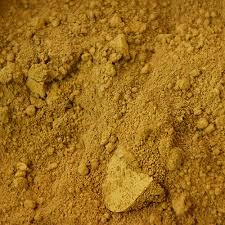

Extracted Soil Properties:
N: 100
P: 50
K: 40
pH: 6.0
Moisture: 60

Top 3 Suitable Crops:
Barley: 40.00%
Wheat: 25.00%
Corn: 24.00%


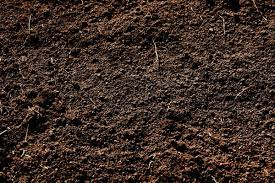

Extracted Soil Properties:
N: 100
P: 50
K: 40
pH: 6.0
Moisture: 60

Top 3 Suitable Crops:
Barley: 40.00%
Wheat: 25.00%
Corn: 24.00%


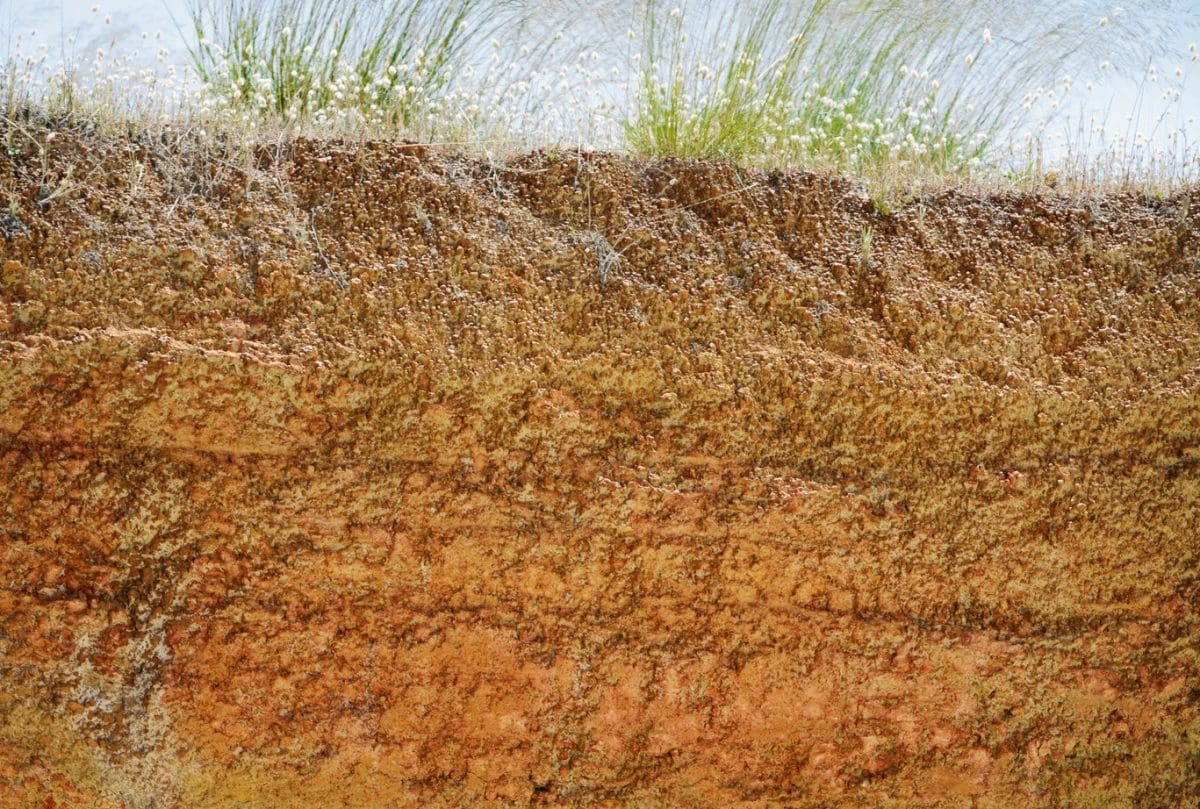

Extracted Soil Properties:
N: 100
P: 50
K: 40
pH: 6.0
Moisture: 60

Top 3 Suitable Crops:
Barley: 40.00%
Wheat: 25.00%
Corn: 24.00%


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import io

# Mock data for soil and crop analysis
crop_data = pd.DataFrame({
    'Crop': ['Wheat', 'Rice', 'Corn', 'Barley', 'Soybean'],
    'N': [120, 90, 140, 80, 100],
    'P': [60, 40, 70, 50, 55],
    'K': [50, 40, 60, 45, 50],
    'pH': [6.5, 5.5, 6.0, 6.5, 6.0],
    'Moisture': [30, 70, 50, 40, 60]
})

# Sample Classifier Model (Using Random Forest)
features = crop_data[['N', 'P', 'K', 'pH', 'Moisture']]
labels = crop_data['Crop']
scaler = StandardScaler()
X = scaler.fit_transform(features)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, labels)

def extract_soil_properties(image_path):
    # Dummy Function - Replace with Image Processing Code
    # For demonstration, we use fixed values
    properties = {
        'N': 100,
        'P': 50,
        'K': 40,
        'pH': 6.0,
        'Moisture': 60
    }
    return properties

def predict_crops(properties):
    data = pd.DataFrame([properties])
    data_scaled = scaler.transform(data)
    predictions = model.predict_proba(data_scaled)[0]
    top_indices = predictions.argsort()[-3:][::-1]
    top_crops = [(labels.iloc[i], predictions[i]) for i in top_indices]
    return top_crops

def on_upload_change(change):
    file_content = change['new'][0]['content']
    image = Image.open(io.BytesIO(file_content))
    image.save('uploaded_image.jpg')
    display(image)

    properties = extract_soil_properties('uploaded_image.jpg')
    print('Extracted Soil Properties:')
    for prop, value in properties.items():
        print(f'{prop}: {value}')

    print('\nTop 3 Suitable Crops:')
    crops = predict_crops(properties)
    for crop, score in crops:
        print(f'{crop}: {score * 100:.2f}%')

upload_button = widgets.FileUpload(
    accept='.jpg, .png',
    multiple=False
)
upload_button.observe(on_upload_change, names='value')

display(upload_button)

FileUpload(value=(), accept='.jpg, .png', description='Upload')

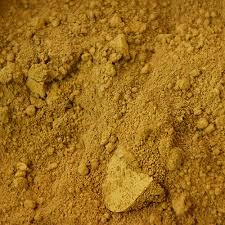

Extracted Soil Properties:
N: 139
P: 56
K: 36
pH: 4.29
Moisture: 18

Top 3 Suitable Crops:
Soybean: 31.00%
Rice: 22.00%
Corn: 21.00%


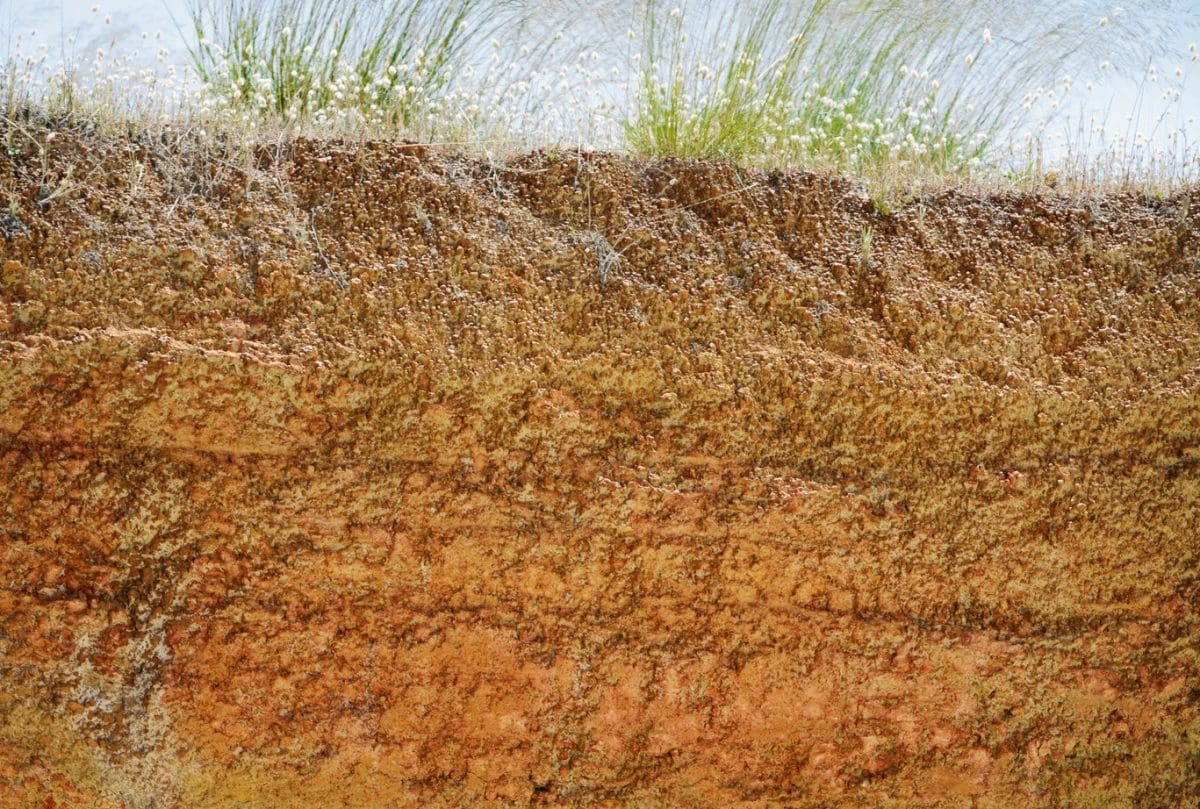

Extracted Soil Properties:
N: 134
P: 38
K: 39
pH: 4.41
Moisture: 45

Top 3 Suitable Crops:
Corn: 36.00%
Rice: 23.00%
Wheat: 19.00%


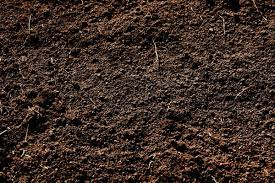

Extracted Soil Properties:
N: 143
P: 29
K: 14
pH: 4.16
Moisture: 57

Top 3 Suitable Crops:
Corn: 41.00%
Rice: 20.00%
Barley: 19.00%


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from IPython.display import display
import ipywidgets as widgets
from PIL import Image
import io

# Mock data for soil and crop analysis
crop_data = pd.DataFrame({
    'Crop': ['Wheat', 'Rice', 'Corn', 'Barley', 'Soybean'],
    'N': [120, 90, 140, 80, 100],
    'P': [60, 40, 70, 50, 55],
    'K': [50, 40, 60, 45, 50],
    'pH': [6.5, 5.5, 6.0, 6.5, 6.0],
    'Moisture': [30, 70, 50, 40, 60]
})

# Sample Classifier Model (Using Random Forest)
features = crop_data[['N', 'P', 'K', 'pH', 'Moisture']]
labels = crop_data['Crop']
scaler = StandardScaler()
X = scaler.fit_transform(features)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X, labels)

def extract_soil_properties(image_path):
    # Read the image
    image = cv2.imread(image_path)
    image = cv2.resize(image, (200, 200))
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Extract average color values
    avg_color = np.mean(hsv_image, axis=(0, 1))
    H, S, V = avg_color / 255.0  # Normalize values
    
    # Estimate soil properties based on color analysis
    N = int((1 - H) * 150)  # Nitrogen
    P = int(S * 70)  # Phosphorus
    K = int(V * 60)  # Potassium
    pH = round(4 + (H * 4), 2)  # pH level
    Moisture = int((1 - S) * 100)  # Soil Moisture

    properties = {
        'N': N,
        'P': P,
        'K': K,
        'pH': pH,
        'Moisture': Moisture
    }
    return properties

def predict_crops(properties):
    data = pd.DataFrame([properties])
    data_scaled = scaler.transform(data)
    predictions = model.predict_proba(data_scaled)[0]
    top_indices = predictions.argsort()[-3:][::-1]
    top_crops = [(labels.iloc[i], predictions[i]) for i in top_indices]
    return top_crops

def on_upload_change(change):
    file_content = change['new'][0]['content']
    image = Image.open(io.BytesIO(file_content))
    image.save('uploaded_image.jpg')
    display(image)

    properties = extract_soil_properties('uploaded_image.jpg')
    print('Extracted Soil Properties:')
    for prop, value in properties.items():
        print(f'{prop}: {value}')

    print('\nTop 3 Suitable Crops:')
    crops = predict_crops(properties)
    for crop, score in crops:
        print(f'{crop}: {score * 100:.2f}%')

upload_button = widgets.FileUpload(
    accept='.jpg, .png',
    multiple=False
)
upload_button.observe(on_upload_change, names='value')

display(upload_button)